## Comparison Figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
real_res = pd.read_csv('C:\\Users\\exmar\\Documents\\BU_Docs\\Classes\\Fall_25\\challenge project\\sgRNAtor\\Elm\\LeTRS_Analysis\\sgrna_count_matrix_real.csv')
sim_res = pd.read_csv('C:\\Users\\exmar\\Documents\\BU_Docs\\Classes\\Fall_25\\challenge project\\sgRNAtor\\Elm\\LeTRS_Analysis\\sgrna_count_matrix.csv')

In [9]:
plot_data = real_res.copy()
#plot_data["sample"] = plot_data["sample"].str.split('-').str[0]
plot_data = plot_data.melt(id_vars = ["sample", "sgRNA"], value_vars=["LeTRS_cluster", "DI-tector", "sgRNAtor"], var_name = "tool", value_name = "count")

#mapping_dict = {"alpha": "Alpha", "beta": "Beta", "delta": "Delta", "omicron": "Omicron", "b.1": "Wuhan", "ba.2": "Omicron", "gamma":"Gamma"}

#plot_data["sample"] = plot_data["sample"].map(mapping_dict)


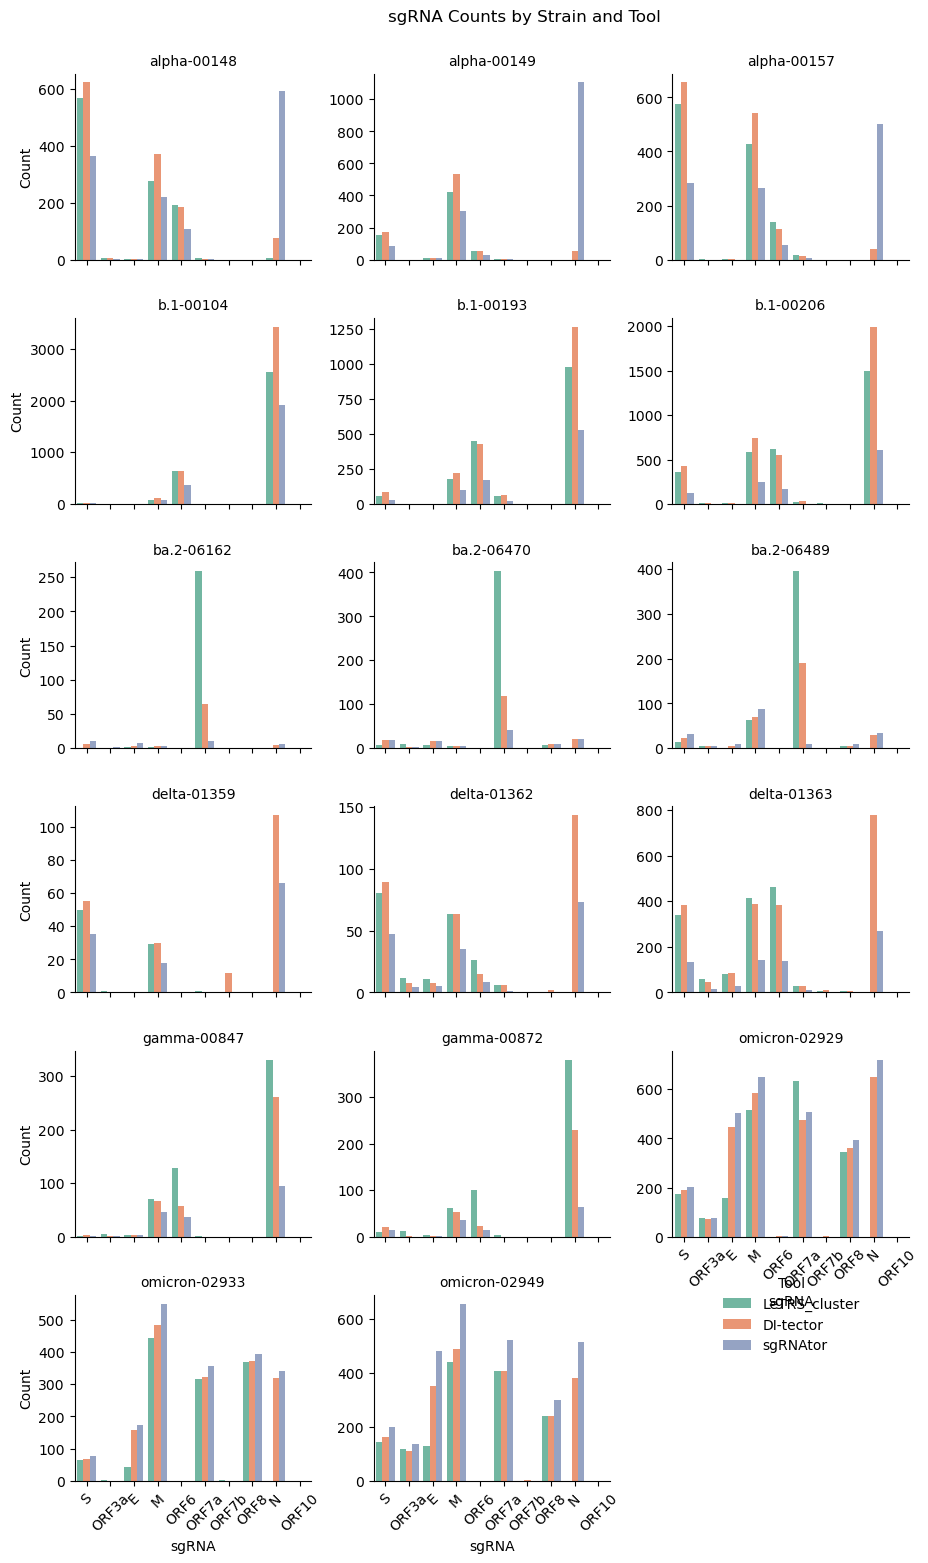

In [11]:
grid = sns.FacetGrid(plot_data, col="sample", col_wrap=3, sharey=False, legend_out=True, height = 2.5, aspect = 1.25)
grid.map(sns.barplot, "sgRNA", "count", data = plot_data, hue = "tool", palette = "Set2", order = plot_data["sgRNA"].unique(), errorbar = None)
grid.set_titles("{col_name}")
grid.set_axis_labels("sgRNA", "Count")
grid.set_xticklabels(labels=plot_data["sgRNA"].unique(), rotation=45)
grid.add_legend(title = "Tool", bbox_to_anchor=(0.82, 0.15))
plt.suptitle("sgRNA Counts by Strain and Tool", y=1.02)
plt.show()

In [19]:
sim_plot_data = sim_res.copy()
sim_plot_data["og_sample"] = sim_plot_data["sample"]
sim_plot_data["sample"] = sim_plot_data["sample"].str[:-5]
sim_plot_data = sim_plot_data.melt(id_vars = ["og_sample","sample", "sgRNA"], value_vars=["LeTRS_cluster", "DI-tector", "sgRNAtor", "ground_truth"], var_name = "tool", value_name = "count")

sim_plot_data = sim_plot_data[sim_plot_data["sample"].isin(["Exponential_Decay", "N_Dominant", "Sparse_1", "Ultra-Sparse_1", "Uniform"])]

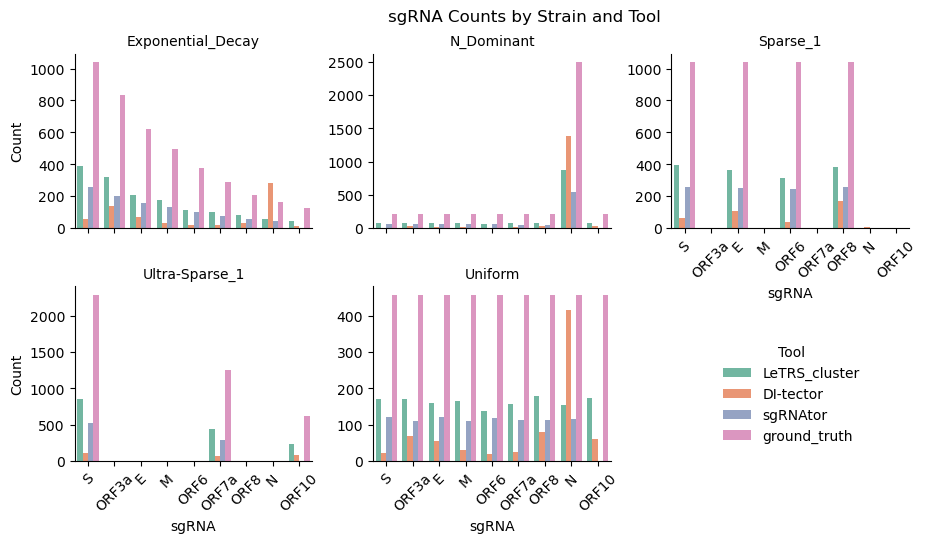

In [8]:
grid = sns.FacetGrid(sim_plot_data, col="sample", col_wrap=3, sharey=False, legend_out=True, height = 2.5, aspect = 1.25)
grid.map(sns.barplot, "sgRNA", "count", data = sim_plot_data, hue = "tool", palette = "Set2", order = sim_plot_data["sgRNA"].unique(), errorbar = None)
grid.set_titles("{col_name}")
grid.set_axis_labels("sgRNA", "Count")
grid.set_xticklabels(labels=sim_plot_data["sgRNA"].unique(), rotation=45)
grid.add_legend(title = "Tool", bbox_to_anchor=(0.82, 0.25))
plt.suptitle("sgRNA Counts by Strain and Tool", y=1.02)
plt.show()

In [20]:
prop_sim_plot = sim_plot_data.copy()
prop_sim_plot["proportion"] = prop_sim_plot.groupby(["og_sample", "tool", "sgRNA"])["count"].transform("sum") / prop_sim_plot.groupby(["og_sample", "tool"])["count"].transform("sum")
#prop_sim_plot["sample"] = prop_sim_plot["sample"].str[:-5]
prop_sim_plot

,og_sample,sample,sgRNA,tool,count,proportion
27,Exponential_Decay_rep1,Exponential_Decay,S,LeTRS_cluster,402.0,0.265522
28,Exponential_Decay_rep1,Exponential_Decay,ORF3a,LeTRS_cluster,319.0,0.210700
29,Exponential_Decay_rep1,Exponential_Decay,E,LeTRS_cluster,189.0,0.124835
30,Exponential_Decay_rep1,Exponential_Decay,M,LeTRS_cluster,182.0,0.120211
31,Exponential_Decay_rep1,Exponential_Decay,ORF6,LeTRS_cluster,109.0,0.071995
...,...,...,...,...,...,...
1291,Uniform_rep3,Uniform,ORF6,ground_truth,458.0,0.111111
1292,Uniform_rep3,Uniform,ORF7a,ground_truth,458.0,0.111111
1293,Uniform_rep3,Uniform,ORF8,ground_truth,458.0,0.111111
1294,Uniform_rep3,Uniform,N,ground_truth,458.0,0.111111


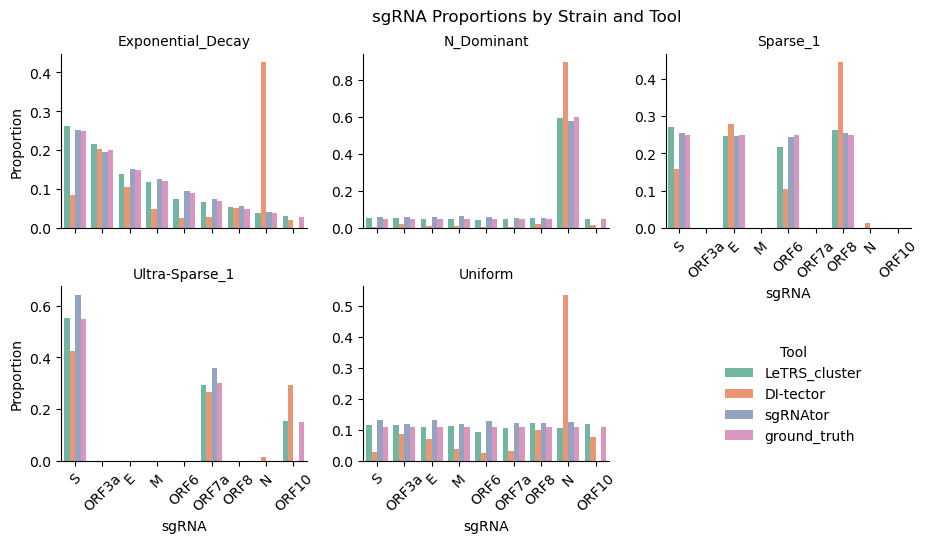

In [21]:
grid = sns.FacetGrid(prop_sim_plot, col="sample", col_wrap=3, sharey=False, legend_out=True, height = 2.5, aspect = 1.25)
grid.map(sns.barplot, "sgRNA", "proportion", data = prop_sim_plot, hue = "tool", palette = "Set2", order = prop_sim_plot["sgRNA"].unique(), errorbar = None)
grid.set_titles("{col_name}")
grid.set_axis_labels("sgRNA", "Proportion")
grid.set_xticklabels(labels=prop_sim_plot["sgRNA"].unique(), rotation=45)
grid.add_legend(title = "Tool", bbox_to_anchor=(0.82, 0.25))
plt.suptitle("sgRNA Proportions by Strain and Tool", y=1.02)
plt.show()

In [24]:
prop_gt_plot = sim_res.copy()
prop_gt_plot["og_sample"] = prop_gt_plot["sample"]
prop_gt_plot["sample"] = prop_gt_plot["sample"].str[:-5]
prop_gt_plot = prop_gt_plot.melt(id_vars = ["og_sample","sample", "sgRNA", "ground_truth"], value_vars=["LeTRS_cluster", "DI-tector", "sgRNAtor"], var_name = "tool", value_name = "count")
prop_gt_plot["proportion"] = prop_gt_plot["count"]/prop_gt_plot["ground_truth"]
#prop_sim_plot["sample"] = prop_sim_plot["sample"].str[:-5]
prop_gt_plot

,og_sample,sample,sgRNA,ground_truth,tool,count,proportion
0,E_Dominant_rep1,E_Dominant,S,208,LeTRS_cluster,66.0,0.317308
1,E_Dominant_rep1,E_Dominant,ORF3a,208,LeTRS_cluster,78.0,0.375000
2,E_Dominant_rep1,E_Dominant,E,2499,LeTRS_cluster,849.0,0.339736
3,E_Dominant_rep1,E_Dominant,M,208,LeTRS_cluster,68.0,0.326923
4,E_Dominant_rep1,E_Dominant,ORF6,208,LeTRS_cluster,69.0,0.331731
...,...,...,...,...,...,...,...
967,Uniform_rep3,Uniform,ORF6,458,sgRNAtor,107.0,0.233624
968,Uniform_rep3,Uniform,ORF7a,458,sgRNAtor,116.0,0.253275
969,Uniform_rep3,Uniform,ORF8,458,sgRNAtor,115.0,0.251092
970,Uniform_rep3,Uniform,N,458,sgRNAtor,107.0,0.233624


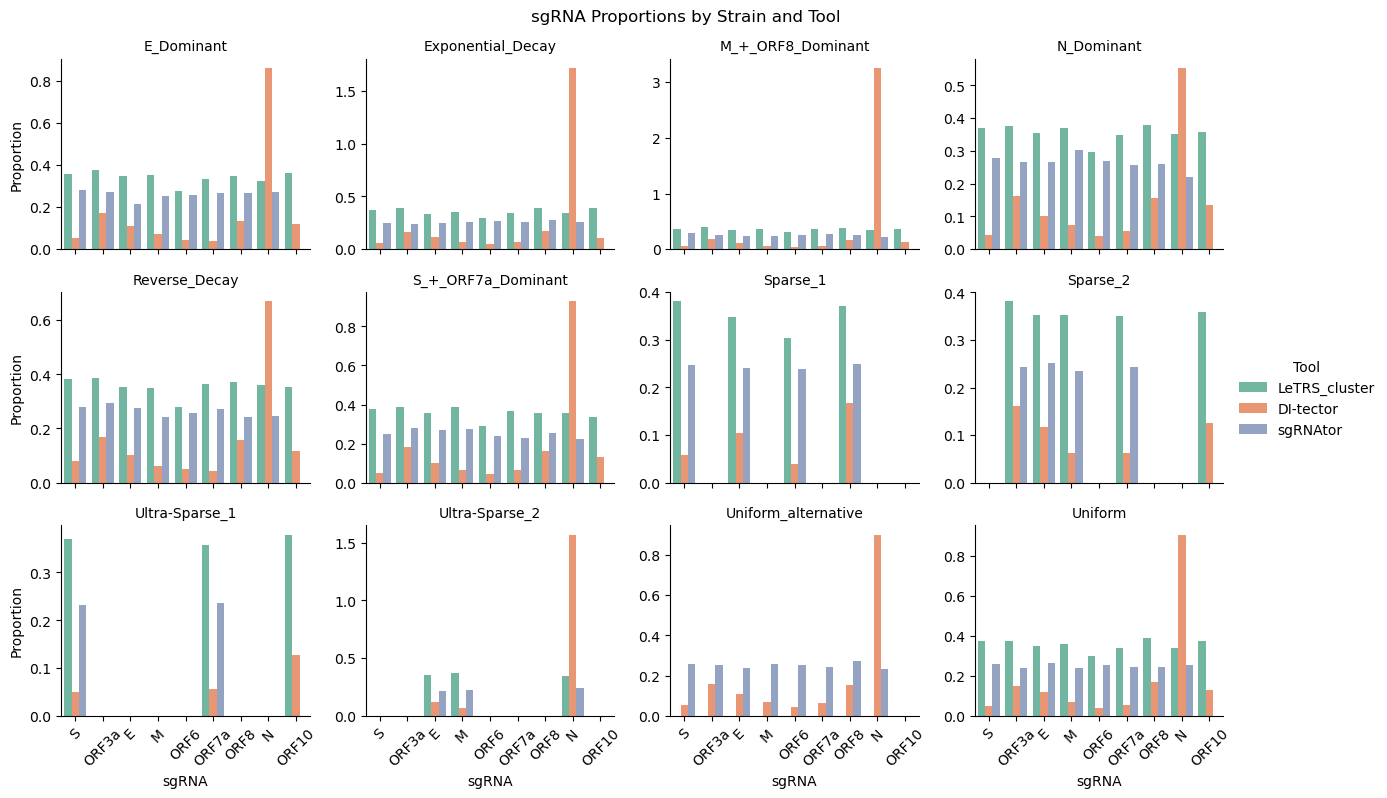

In [27]:
grid = sns.FacetGrid(prop_gt_plot, col="sample", col_wrap=4, sharey=False, legend_out=True, height = 2.5, aspect = 1.25)
grid.map(sns.barplot, "sgRNA", "proportion", data = prop_gt_plot, hue = "tool", palette = "Set2", order = prop_gt_plot["sgRNA"].unique(), errorbar = None)
grid.set_titles("{col_name}")
grid.set_axis_labels("sgRNA", "Proportion")
grid.set_xticklabels(labels=prop_gt_plot["sgRNA"].unique(), rotation=45)
grid.add_legend(title = "Tool")
plt.suptitle("sgRNA Proportions by Strain and Tool", y=1.02)
plt.show()